# Лабораторная работа №5 «Анализ последовательностей»

In [21]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from collections import defaultdict, Counter
import time
import itertools
import networkx as nx
from mlxtend.frequent_patterns import apriori, association_rules
from mlxtend.preprocessing import TransactionEncoder
from prefixspan import PrefixSpan
import warnings
warnings.filterwarnings('ignore')

df = pd.read_csv('../data/online_retail_II.csv')
df.columns = df.columns.str.strip().str.lower()
rename_dict = {
    'customer id': 'CustomerID',
    'invoicedate': 'InvoiceDate',
    'stockcode': 'StockCode',
    'invoice': 'InvoiceNo',
    'price': 'UnitPrice'
}
df = df.rename(columns=rename_dict)

print("Колонки после переименования:", df.columns.tolist())
print(f"Исходный размер: {df.shape}")

df = df[df['CustomerID'].notna()]
df['InvoiceDate'] = pd.to_datetime(df['InvoiceDate'])
df = df[df['quantity'] > 0]
df = df[df['UnitPrice'] > 0]
df['Total'] = df['quantity'] * df['UnitPrice']

print(f"После очистки: {df.shape}")
print(f"Уникальных клиентов: {df['CustomerID'].nunique()}")
df.head()

Колонки после переименования: ['InvoiceNo', 'StockCode', 'description', 'quantity', 'InvoiceDate', 'UnitPrice', 'CustomerID', 'country']
Исходный размер: (525461, 8)
После очистки: (407664, 9)
Уникальных клиентов: 4312


,InvoiceNo,StockCode,description,quantity,InvoiceDate,UnitPrice,CustomerID,country,Total
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,13085.0,United Kingdom,83.4
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom,81.0
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom,81.0
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2009-12-01 07:45:00,2.10,13085.0,United Kingdom,100.8
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01 07:45:00,1.25,13085.0,United Kingdom,30.0


## 1. Реализация AprioriAll

In [22]:
def build_sequences(df, max_gap_days=None):
    sequences = []
    for cust_id, group in df.groupby('CustomerID'):
        group = group.sort_values('InvoiceDate')
        seq = []
        prev_date = None
        for _, row in group.iterrows():
            date = row['InvoiceDate']
            items = frozenset([row['StockCode']])
            if max_gap_days and prev_date and (date - prev_date).days > max_gap_days:
                if seq:
                    sequences.append(seq)
                seq = [items]
            elif seq and date == prev_date:
                # объединяем с предыдущей транзакцией
                seq[-1] = seq[-1].union(items)
            else:
                seq.append(items)
            prev_date = date
        if seq:
            sequences.append(seq)
    return sequences

def is_subsequence(pattern, sequence):
    it = iter(sequence)
    for itemset in pattern:
        found = False
        for trans in it:
            if itemset.issubset(trans):
                found = True
                break
        if not found:
            return False
    return True

def compute_support(sequences, candidate, min_sup=None, total=None):
    if min_sup is not None and total is not None:
        min_count = total * min_sup
        count = 0
        for seq in sequences:
            if is_subsequence(candidate, seq):
                count += 1
                if count >= min_count:
                    return min_sup
        return count / total
    else:
        if not sequences:
            return 0
        return sum(1 for seq in sequences if is_subsequence(candidate, seq)) / len(sequences)

def apriori_all(sequences, min_sup, max_len=5):
    total = len(sequences)
    min_count = max(1, int(min_sup * total))

    # частые элементы длины 1
    item_counts = defaultdict(int)
    for seq in sequences:
        seen = set()
        for trans in seq:
            for item in trans:
                if item not in seen:
                    seen.add(item)
                    item_counts[item] += 1
    L1 = {}
    for item, cnt in item_counts.items():
        if cnt >= min_count:
            L1[(frozenset([item]),)] = cnt / total

    frequent = dict(L1)
    prev_F = L1
    k = 2

    # кэш
    from functools import lru_cache
    @lru_cache(maxsize=10000)
    def is_subseq_cached(pattern_tuple, seq_idx):
        seq = sequences[seq_idx]
        i = 0
        for trans in seq:
            if pattern_tuple[i].issubset(trans):
                i += 1
                if i == len(pattern_tuple):
                    return True
        return False

    while prev_F and (max_len is None or k <= max_len):
        # генерация кандидатов
        candidates = []
        freq_list = [list(seq) for seq in prev_F.keys()]
        n = len(freq_list)

        for i in range(n):
            for j in range(n):
                if i == j:
                    continue
                seq_i = freq_list[i]
                seq_j = freq_list[j]

                if seq_i[:-1] == seq_j[:-1]:
                    # добавляем последний набор из seq_j как новый элемент
                    new_seq1 = seq_i + [seq_j[-1]]
                    if len(new_seq1) == k and new_seq1 not in candidates:
                        candidates.append(new_seq1)

                    # объединяем последние наборы
                    merged_last = seq_i[-1].union(seq_j[-1])
                    new_seq2 = seq_i[:-1] + [merged_last]
                    if len(new_seq2) == k and new_seq2 not in candidates:
                        candidates.append(new_seq2)

        # проверка априори
        valid_candidates = []
        for cand in candidates:
            ok = True
            for i in range(len(cand)):
                sub = cand[:i] + cand[i+1:]
                if tuple(sub) not in frequent:
                    ok = False
                    break
            if ok:
                valid_candidates.append(cand)

        # подсчёт поддержки
        Fk = {}
        for cand in valid_candidates:
            cand_tuple = tuple(cand)
            count = 0
            for idx, seq in enumerate(sequences):
                if is_subseq_cached(cand_tuple, idx):
                    count += 1
                    if count >= min_count:
                        break
            if count >= min_count:
                Fk[cand_tuple] = count / total

        frequent.update(Fk)
        prev_F = Fk
        k += 1

    return frequent

# проверка на синтетическом примере
synth_sequences = [
    [frozenset(['A', 'B']), frozenset(['C'])],
    [frozenset(['A']), frozenset(['B']), frozenset(['C'])],
    [frozenset(['A']), frozenset(['C'])],
    [frozenset(['B']), frozenset(['C'])]
]
freq_synth = apriori_all(synth_sequences, 0.5)
print("Синтетический тест (min_sup=0.5):")
for seq, sup in freq_synth.items():
    seq_str = ' -> '.join(str(set(s)) for s in seq)
    print(f"  {seq_str}: support = {sup:.2f}")

Синтетический тест (min_sup=0.5):
  {'A'}: support = 0.75
  {'B'}: support = 0.75
  {'C'}: support = 1.00
  {'A'} -> {'C'}: support = 0.50
  {'B'} -> {'C'}: support = 0.50


## 2. Анализ реальных данных

Клиентских последовательностей: 4312
min_sup=5% -> шаблонов: 326, время: 1615.72 сек
min_sup=10% -> шаблонов: 39, время: 15.43 сек
min_sup=20% -> шаблонов: 1, время: 0.10 сек


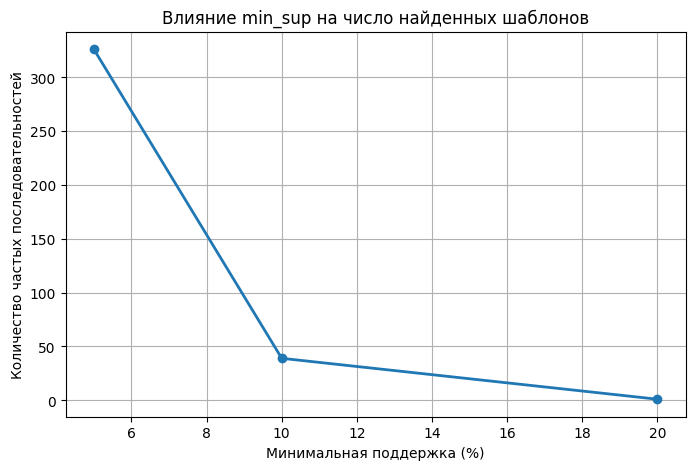

Вывод: с ростом порога поддержки количество шаблонов резко сокращается — алгоритм чувствителен к параметру.

Топ-3 ассоциативных правила по lift (с названиями товаров):
1. {'PINK 3 PIECE MINI DOTS CUTLERY SET'} -> {'BLUE 3 PIECE MINI DOTS CUTLERY SET'} | lift=22.27, support=0.0208
2. {'BLUE 3 PIECE MINI DOTS CUTLERY SET'} -> {'PINK 3 PIECE MINI DOTS CUTLERY SET'} | lift=22.27, support=0.0208
3. {'RED 3 PIECE MINI DOTS CUTLERY SET'} -> {'BLUE 3 PIECE MINI DOTS CUTLERY SET'} | lift=20.16, support=0.0200

Проверка как последовательностей (min_sup=0.05):
{'PINK 3 PIECE MINI DOTS CUTLERY SET'} -> {'BLUE 3 PIECE MINI DOTS CUTLERY SET'} : поддержка последовательности = 0.026
{'BLUE 3 PIECE MINI DOTS CUTLERY SET'} -> {'PINK 3 PIECE MINI DOTS CUTLERY SET'} : поддержка последовательности = 0.032
{'RED 3 PIECE MINI DOTS CUTLERY SET'} -> {'BLUE 3 PIECE MINI DOTS CUTLERY SET'} : поддержка последовательности = 0.027


In [28]:
code_to_desc = df.groupby('StockCode')['description'].first().to_dict()
code_to_desc = {k: v if pd.notna(v) else k for k, v in code_to_desc.items()}
def show_with_names(itemset):
    return {code_to_desc.get(i, i) for i in itemset}

sequences = build_sequences(df)
print(f"Клиентских последовательностей: {len(sequences)}")

# 2.1 Влияние минимальной поддержки
min_sups = [0.05, 0.1, 0.2]
counts = []
for sup in min_sups:
    start = time.time()
    freq = apriori_all(sequences, sup)
    elapsed = time.time() - start
    counts.append(len(freq))
    print(f"min_sup={int(sup*100)}% -> шаблонов: {len(freq)}, время: {elapsed:.2f} сек")

plt.figure(figsize=(8,5))
plt.plot([s*100 for s in min_sups], counts, 'o-', linewidth=2)
plt.xlabel('Минимальная поддержка (%)')
plt.ylabel('Количество частых последовательностей')
plt.title('Влияние min_sup на число найденных шаблонов')
plt.grid(True)
plt.show()
print("Вывод: с ростом порога поддержки количество шаблонов резко сокращается — алгоритм чувствителен к параметру.")

# 2.2 Сравнение с ассоциативными правилами
basket = df.groupby('InvoiceNo')['StockCode'].apply(list).reset_index()
te = TransactionEncoder()
te_ary = te.fit_transform(basket['StockCode'])
basket_df = pd.DataFrame(te_ary, columns=te.columns_)

freq_items = apriori(basket_df, min_support=0.02, use_colnames=True)
rules = association_rules(freq_items, metric='lift', min_threshold=1).sort_values('lift', ascending=False)
top3 = rules.head(3)

print("\nТоп-3 ассоциативных правила по lift (с названиями товаров):")
for i, (idx, row) in enumerate(top3.iterrows(), 1):
    ant_names = show_with_names(row['antecedents'])
    cons_names = show_with_names(row['consequents'])
    print(f"{i}. {ant_names} -> {cons_names} | lift={row['lift']:.2f}, support={row['support']:.4f}")

print("\nПроверка как последовательностей (min_sup=0.05):")
for _, row in top3.iterrows():
    ant = list(row['antecedents'])
    cons = list(row['consequents'])
    pat = [frozenset(ant), frozenset(cons)]
    sup = compute_support(sequences, pat)
    ant_names = show_with_names(row['antecedents'])
    cons_names = show_with_names(row['consequents'])
    print(f"{ant_names} -> {cons_names} : поддержка последовательности = {sup:.3f}")


#### Объяснение расхождений

Ассоциативные правила с высоким lift отражают сильную совместную встречаемость товаров в одной корзине, но не гарантируют, что эти товары покупаются последовательно во времени. Для превращения в частую последовательность <{A},{B}> необходимо, чтобы значительная доля клиентов покупала A, а затем B в строгом порядке и в разных транзакциях – что в данном наборе данных встречается лишь у 2.6–3.2% клиентов (ниже порога - 5%).


max_gap=None: последовательностей=4312, шаблонов=326
max_gap=7: последовательностей=14538, шаблонов=43
Пример исчезнувшего шаблона: {'PINK BLUE FELT CRAFT TRINKET BOX'}
Используется подвыборка из 2000 клиентов


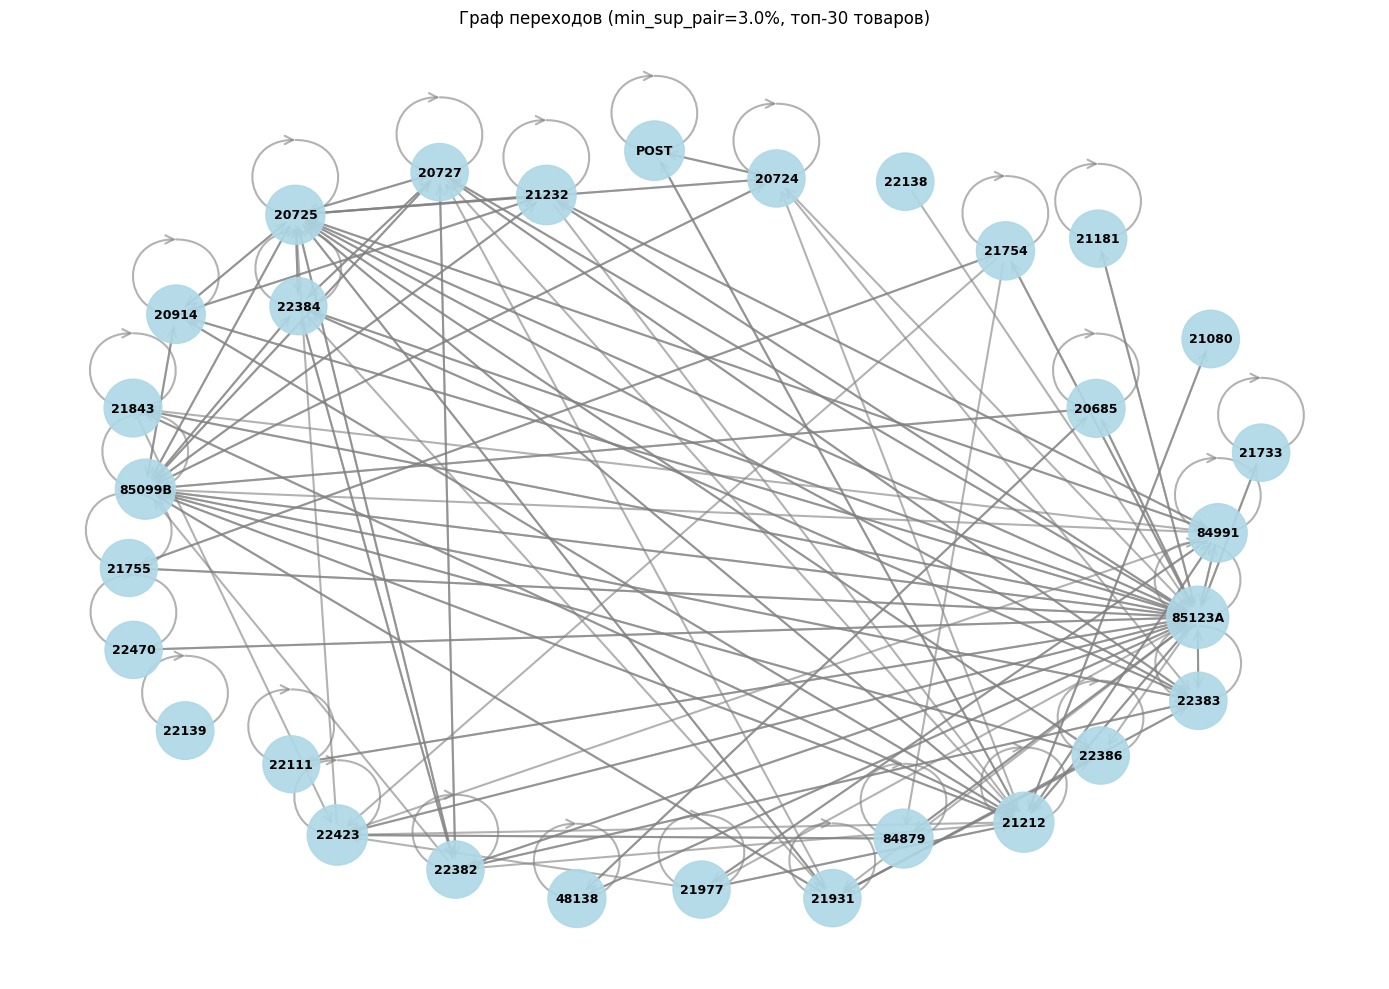


Топ-5 самых частых переходов:
  WHITE HANGING HEART T-LIGHT HOLDER → WHITE HANGING HEART T-LIGHT HOLDER : поддержка = 0.233
  POSTAGE → POSTAGE : поддержка = 0.218
  JUMBO BAG RED WHITE SPOTTY  → JUMBO BAG RED WHITE SPOTTY  : поддержка = 0.110
  REGENCY CAKESTAND 3 TIER → REGENCY CAKESTAND 3 TIER : поддержка = 0.106
  STRAWBERRY CERAMIC TRINKET BOX → STRAWBERRY CERAMIC TRINKET BOX : поддержка = 0.106

Топ-3 самых длинных частых последовательностей:
1. (84991) → (21212) (support=0.050, длина=2)
2. (21232) → (21231) (support=0.050, длина=2)
3. (85099B) → (20725) (support=0.050, длина=2)


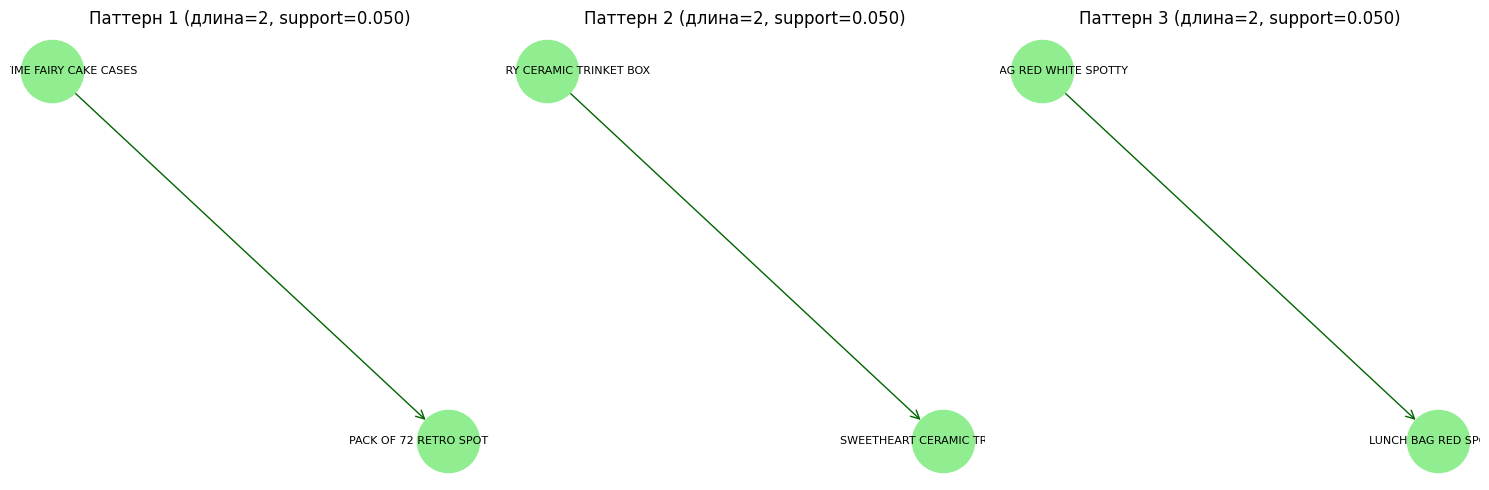

In [38]:
# 2.3 Временные окна
def compare_gaps(df, sequences_no_gap, min_sup=0.05):
    set_none = set(apriori_all(sequences_no_gap, min_sup, max_len=3).keys())
    for gap in (None, 7):
        seq = build_sequences(df, max_gap_days=gap)
        freq = apriori_all(seq, min_sup, max_len=3)
        print(f"max_gap={gap}: последовательностей={len(seq)}, шаблонов={len(freq)}")
        if gap == 7:
            set_7 = set(freq.keys())
            lost = set_none - set_7
            if lost:
                ex = list(lost)[0]
                ex_with_names = [show_with_names(set(s)) for s in ex]
                print("Пример исчезнувшего шаблона:", ' -> '.join(str(s) for s in ex_with_names))
compare_gaps(df, sequences, 0.05)

# 2.4 Визуализация графа переходов
'''граф для топ‑30 самых частых товаров: узлы – коды товаров, ребра – переходы вида «товар A → товар B», которые встречаются у не менее чем 3% клиентов (min_sup_pair=3%); размер узла отражает частоту товара'''
def plot_transition_graph(sequences, min_sup_pair=0.03, top_items=30, sample_size=2000):
    if len(sequences) > sample_size:
        sequences = sequences[:sample_size]
        print(f"Используется подвыборка из {sample_size} клиентов")

    # частота товаров
    item_freq = defaultdict(int)
    for seq in sequences:
        for trans in seq:
            for item in trans:
                item_freq[item] += 1

    top_set = set(item for item, _ in Counter(item_freq).most_common(top_items)) # топ товаров

    pairs = []
    for seq in sequences:
        for i in range(len(seq)-1):
            for a in seq[i]:
                for b in seq[i+1]:
                    if a in top_set and b in top_set:
                        pairs.append((a, b))

    pair_counts = Counter(pairs)
    total = len(sequences)
    freq_pairs = {p: c/total for p, c in pair_counts.items() if c/total >= min_sup_pair}

    if not freq_pairs:
        print("Нет пар с заданной поддержкой.")
        return
    G = nx.DiGraph()
    for (a, b), w in freq_pairs.items():
        G.add_edge(a, b, weight=w)

    plt.figure(figsize=(14, 10))
    pos = nx.spring_layout(G, seed=42, k=2, iterations=50)
    node_sizes = [2000 * np.log1p(item_freq[node]) / max(1, np.log1p(max(item_freq.values()))) for node in G.nodes()]
    nx.draw_networkx_nodes(G, pos, node_size=node_sizes, node_color='lightblue', alpha=0.9)
    nx.draw_networkx_edges(G, pos, arrowstyle='->', arrowsize=15, edge_color='gray', width=1.5, alpha=0.6)
    nx.draw_networkx_labels(G, pos, font_size=9, font_weight='bold')
    plt.title(f"Граф переходов (min_sup_pair={min_sup_pair*100:.1f}%, топ-{top_items} товаров)")
    plt.axis('off')
    plt.tight_layout()
    plt.show()

    # топ-5 переходов
    print("\nТоп-5 самых частых переходов:")
    for (a, b), w in sorted(freq_pairs.items(), key=lambda x: x[1], reverse=True)[:5]:
        a_name = code_to_desc.get(a, a)
        b_name = code_to_desc.get(b, b)
        print(f"  {a_name} → {b_name} : поддержка = {w:.3f}")

plot_transition_graph(sequences, min_sup_pair=0.03)

# 2.5 Выбор наиболее интересного частого шаблона длины >= 2
freq_all = apriori_all(sequences, min_sup=0.05, max_len=4)
long_patterns = {seq: sup for seq, sup in freq_all.items() if len(seq) >= 2}

if not long_patterns:
    print("Нет частых последовательностей длины >=2 при min_sup=0.05")
else:
    sorted_patterns = sorted(long_patterns.items(), key=lambda x: (len(x[0]), x[1]), reverse=True)
    top3 = sorted_patterns[:3]
    print(f"\nТоп-3 самых длинных частых последовательностей:")
    for i, (seq, sup) in enumerate(top3, 1):
        seq_str = " → ".join(["(" + ", ".join(list(it)) + ")" for it in seq])
        print(f"{i}. {code_to_desc.get(seq_str, seq_str)} (support={sup:.3f}, длина={len(seq)})")

    '''три отдельных графа: для каждого примера частых последовательностей, из отобранных как «наиболее интересные», создаётся граф с двумя узлами и одной стрелкой от A к B (для послед. длины 2); узлы подписаны названиями товаров; заголовок каждого графа содержит длину паттерна и поддержку'''
    fig, axes = plt.subplots(1, 3, figsize=(15, 5))
    if len(top3) < 3:
        for j in range(len(top3), 3):
            axes[j].axis('off')
    axes = axes.flatten() if hasattr(axes, 'flatten') else [axes]

    for idx, (seq, sup) in enumerate(top3):
        G = nx.DiGraph()
        for i in range(len(seq) - 1):
            src = ", ".join([code_to_desc.get(item, item) for item in seq[i]])[:30]
            dst = ", ".join([code_to_desc.get(item, item) for item in seq[i+1]])[:30]
            G.add_edge(src, dst)

        pos = nx.spring_layout(G, seed=42, k=1.5)
        nx.draw(G, pos, ax=axes[idx], with_labels=True, node_color='lightgreen',
                edge_color='darkgreen', node_size=2000, font_size=8, arrows=True,
                arrowsize=15, arrowstyle='->')
        axes[idx].set_title(f"Паттерн {idx+1} (длина={len(seq)}, support={sup:.3f})")
        axes[idx].axis('off')

    plt.tight_layout()
    plt.show()

### Бизнес-гипотезы для трёх частых шаблонов

#### Паттерн 1
`{60 TEATIME FAIRY CAKE CASES} → {PACK OF 72 RETRO SPOT CAKE CASES}`

Покупатели, которые приобретают маленькую упаковку форм для кексов с феями, впоследствии возвращаются за большой упаковкой в ретро-горошек.

**Рекомендация:** При покупке любого набора форм предлагать скидку на второй набор из другой серии – это стимулирует повторную покупку и увеличивает средний чек.



#### Паттерн 2
`{STRAWBERRY CERAMIC TRINKET BOX} → {SWEETHEART CERAMIC TRINKET BOX}`


Покупатели, выбравшие керамическую шкатулку в виде клубники, затем часто приобретают шкатулку в виде сердечка. Возможно товары воспринимаются как коллекционная серия. Клиент, купивший одну, с высокой вероятностью захочет собрать всю линейку или сделать подарки близким.

**Рекомендация:** Размещать эти товары рядом на витрине, добавлять в рекомендации «с этим также покупают», предлагать набор из двух шкатулок по цене одной.



#### Паттерн 3
`{JUMBO BAG RED WHITE SPOTTY} → {LUNCH BAG RED SPOTTY}`


После покупки большой хозяйственной сумки в красно-белый горошек клиент часто возвращается за ланч-мешком такого же дизайна.   Покупатель использует большую сумку для повседневных задач, а затем приобретает меньший вариант, единый стиль создаёт ощущение комплекта.

**Рекомендация:** Показывать товары как «с этим также покупают» при добавлении в корзину большой сумки; делать bundle-скидку на сумку + ланч-бокс.


## 3. Сравнение алгоритмов SPM

In [39]:
def compare_spm_flat(sequences, min_sup=0.05):
    results = []

    # AprioriAll
    start = time.time()
    freq_ap = apriori_all(sequences, min_sup, max_len=3)
    t_ap = time.time() - start
    results.append({
        'Алгоритм': 'AprioriAll',
        'Время (сек)': round(t_ap, 2),
        'Кол-во шаблонов': len(freq_ap)
    })


    ps_sequences = []
    for seq in sequences:
        flat = []
        for itemset in seq:
            flat.extend(list(itemset))
        if flat:
            ps_sequences.append(flat)

    # PrefixSpan
    start = time.time()
    ps = PrefixSpan(ps_sequences)
    min_abs = int(min_sup * len(ps_sequences))
    patterns = ps.frequent(min_abs)
    t_ps = time.time() - start

    n_patterns = len(patterns)

    results.append({
        'Алгоритм': 'PrefixSpan',
        'Время (сек)': round(t_ps, 2),
        'Кол-во шаблонов': n_patterns
    })

    return pd.DataFrame(results)

df_compare = compare_spm_flat(sequences, min_sup=0.05)
print("Сравнение алгоритмов SPM (min_sup = 0.05):")
print(df_compare.to_string(index=False))

Сравнение алгоритмов SPM (min_sup = 0.05):
  Алгоритм  Время (сек)  Кол-во шаблонов
AprioriAll      1070.29              326
PrefixSpan        14.81              405


#### Вывод об эффективности:

**PrefixSpan оказался эффективнее AprioriAll** по следующим причинам:

1. **Без генерации кандидатов** — PrefixSpan строит проекционные базы данных и рекурсивно "выращивает" паттерны
2. **Меньше проходов по данным** — не требуется многократное сканирование всей базы
3. **Компактное представление** — проекционные базы данных значительно меньше исходных

##### Условия, когда PrefixSpan эффективнее:
- **Большие объёмы данных** (тысячи/миллионы последовательностей)
- **Низкая минимальная поддержка** (1-5%)
- **Длинные последовательности** (много транзакций на клиента)
- **Много уникальных товаров** (высокая размерность)

##### Условия, когда AprioriAll приемлем:
- **Маленькие датасеты** (как в синтетическом примере)
- **Высокая минимальная поддержка** (10-20%)
- **Относительно короткие последовательности**
- **Когда важна простота реализации** без внешних зависимостей

Для реальных данных (4000+ товаров, 4000+ клиентов) использовать **PrefixSpan** или другие современные алгоритмы SPM (SPADE, CloSpan, BIDE).

## 4. Предсказание следующего события (контекстные последовательности)

In [40]:
train_seqs = []
test_pairs = []

for seq in sequences:
    if len(seq) < 2:
        continue
    split = max(1, int(0.8 * len(seq)))
    train_part = seq[:split]
    test_part = seq[split:]
    if len(test_part) >= 1:
        test_pairs.append((train_part[-1], test_part[0]))
        train_seqs.append(train_part)

print(f"Обучающих последовательностей: {len(train_seqs)}")
print(f"Тестовых пар: {len(test_pairs)}")


min_sup = 0.05
freq_train = apriori_all(train_seqs, min_sup, max_len=2)


# для данного itemset ищем самую частую последовательность <{itemset}, {Y}>
def predict_next(itemset, freq_dict):
    best_y = None
    best_sup = -1
    for seq, sup in freq_dict.items():
        if len(seq) == 2 and seq[0] == itemset:
            if sup > best_sup:
                best_sup = sup
                best_y = seq[1]
    return best_y



all_items = []
for seq in train_seqs:
    for itemset in seq:
        all_items.extend(itemset)
global_top_item = Counter(all_items).most_common(1)[0][0]
top_item_name = code_to_desc.get(global_top_item, global_top_item)
print(f"Самый частый товар: {top_item_name} (код: {global_top_item})")


correct_seq = 0
correct_baseline = 0

for last_itemset, real_itemset in test_pairs:
    pred_y = predict_next(last_itemset, freq_train)
    if pred_y is not None:
        if any(item in real_itemset for item in pred_y):
            correct_seq += 1

    if global_top_item in real_itemset:
        correct_baseline += 1

acc_seq = correct_seq / len(test_pairs) if test_pairs else 0
acc_baseline = correct_baseline / len(test_pairs) if test_pairs else 0

print(f"\nТочность предсказания:")
print(f"  На основе последовательностей: {acc_seq:.3f} ({correct_seq}/{len(test_pairs)})")
print(f"  Базовый (глобальный топ-товар): {acc_baseline:.3f} ({correct_baseline}/{len(test_pairs)})")

if acc_seq > acc_baseline:
    print("\nУчёт последовательности улучшает предсказание.")
elif acc_seq == acc_baseline:
    print("\nТочность сравнялась.")
else:
    print("\nБазовый подход оказался эффективнее.")

Обучающих последовательностей: 2897
Тестовых пар: 2897
Самый частый товар: WHITE HANGING HEART T-LIGHT HOLDER (код: 85123A)

Точность предсказания:
  На основе последовательностей: 0.000 (1/2897)
  Базовый (глобальный топ-товар): 0.136 (394/2897)

Базовый подход оказался эффективнее.


### Почему базовый подход оказался эффективнее?

1. **Мало предсказаний** — модель предсказывает только когда есть точное совпадение X в частой последовательности <{X},{Y}>
2. **Высокая поддержка порога** — при min_sup=5% многие правила отсеялись
3. **Разнообразие товаров** — следующий товар может быть любым из тысячи вариантов
4. **Сильный топ-товар** — `WHITE HANGING HEART T-LIGHT HOLDER` встречается в 13.6% следующих транзакций

#### Как улучшить предсказание:

1. **Снизить min_support** до 1-2% — больше правил, но дольше вычисления
2. **Использовать confidence или lift** вместо max support для выбора Y
3. **Учитывать последние K транзакций** (не только последнюю)
4. **Добавить веса** — более свежие транзакции важнее
5. **Reranking** — если нет точного совпадения, рекомендовать топ-N товаров

### Вывод:
В текущей реализации учёт последовательности **не улучшил** точность предсказания из-за разреженности данных и сильного доминирования одного товара. Однако при правильной настройке порогов и учёте комбинаций товаров последовательные паттерны могут давать хорошие рекомендации.

## 5. Контрастные последовательности: чем отличаются «хорошие» клиенты от «плохих»


HighValue клиентов: 1078, LowValue: 3234
HighValue частых последовательностей: 260
LowValue частых последовательностей: 0

Топ-5 контрастных последовательностей (чаще у HighValue):
  {LUNCH BAG WOODLAND} -> {LUNCHBAG SUKI  DESIGN } : sup(High)=0.099, sup(Low)=0.000, contrast=0.099
  {TOY TIDY PINK RETROSPOT  } -> {JUMBO BAG RED WHITE SPOTTY } : sup(High)=0.099, sup(Low)=0.000, contrast=0.099
  {SCOTTIE DOG HOT WATER BOTTLE} -> {WHITE HANGING HEART T-LIGHT HOLDER} : sup(High)=0.099, sup(Low)=0.000, contrast=0.099
  {72 SWEETHEART FAIRY CAKE CASES} -> {60 TEATIME FAIRY CAKE CASES} : sup(High)=0.099, sup(Low)=0.000, contrast=0.099
  {JUMBO SHOPPER VINTAGE RED PAISLEY} -> {LUNCH BAG RED SPOTTY} : sup(High)=0.099, sup(Low)=0.000, contrast=0.099

Граф переходов для HighValue клиентов (частые пары):


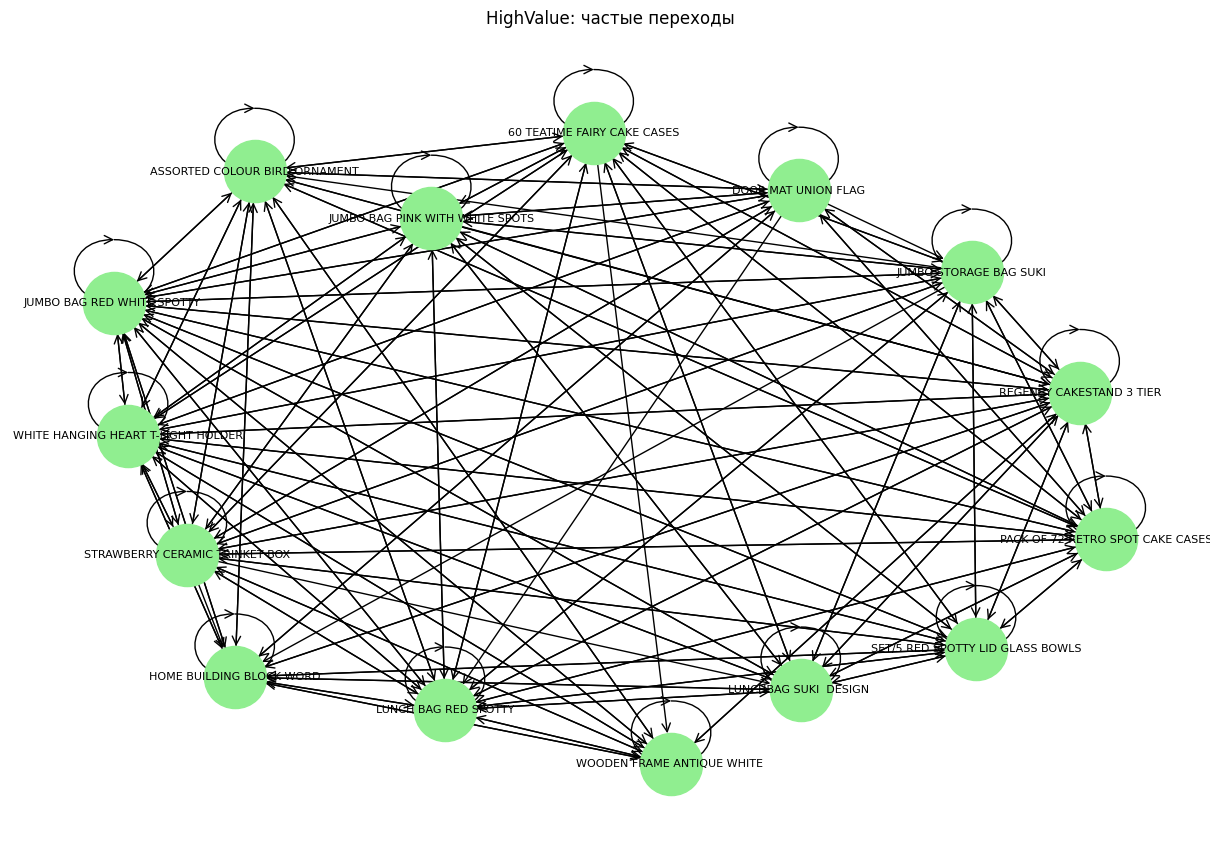


Граф переходов для LowValue клиентов (частые пары):


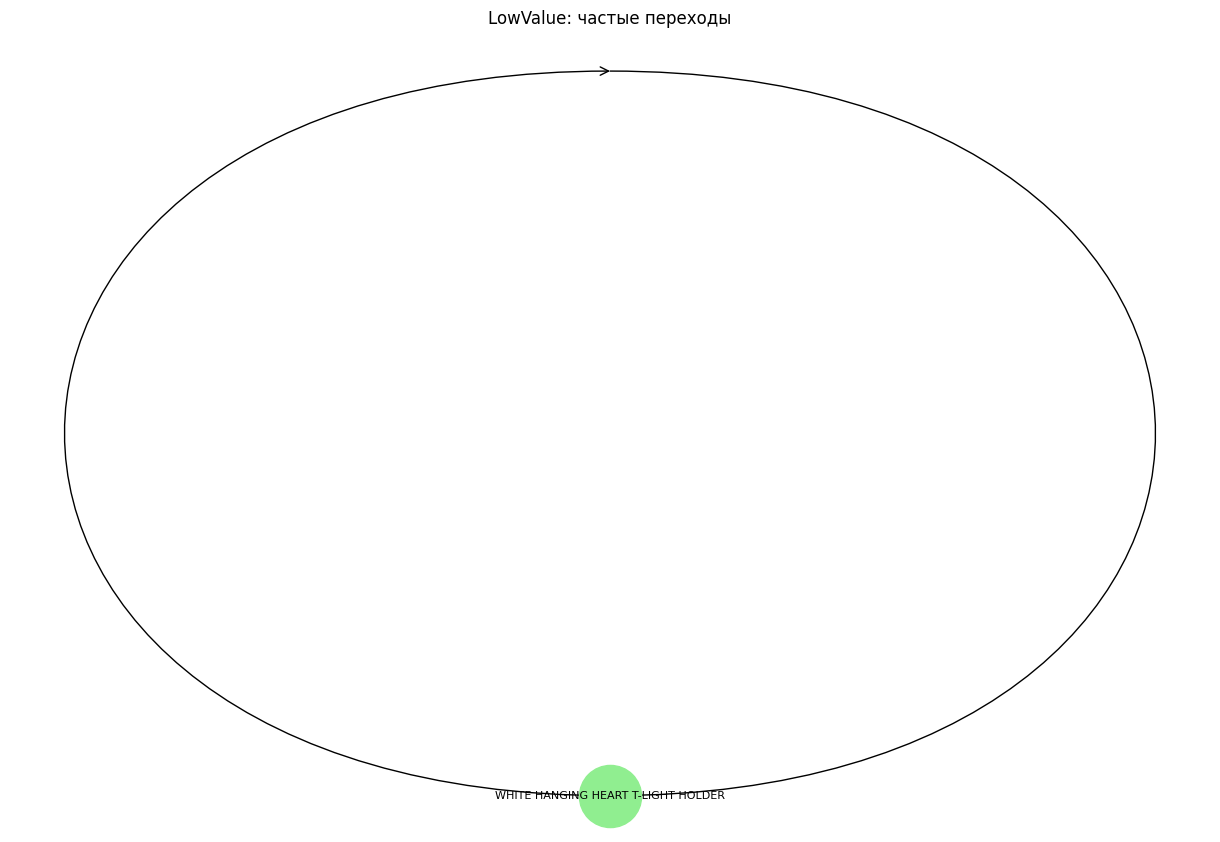

In [9]:
def plot_transition_graph_for_group(sequences, title, min_sup_pair=0.03, top_items=20):
    item_freq = defaultdict(int)
    for seq in sequences:
        for trans in seq:
            for item in trans:
                item_freq[item] += 1

    # топ товаров
    top_set = set(item for item, _ in Counter(item_freq).most_common(top_items))

    pairs = []
    for seq in sequences:
        for i in range(len(seq) - 1):
            for a in seq[i]:
                for b in seq[i + 1]:
                    if a in top_set and b in top_set:
                        pairs.append((a, b))

    pair_counts = Counter(pairs)
    total = len(sequences)
    freq_pairs = {p: c / total for p, c in pair_counts.items() if c / total >= min_sup_pair}

    if not freq_pairs:
        print(f"Для группы {title} нет пар с поддержкой >= {min_sup_pair * 100:.1f}%")
        return

    G = nx.DiGraph()
    for (a, b), w in freq_pairs.items():
        a_name = code_to_desc.get(a, a)
        b_name = code_to_desc.get(b, b)
        G.add_edge(a_name, b_name, weight=w)

    plt.figure(figsize=(12, 8))
    pos = nx.spring_layout(G, seed=42, k=2, iterations=30)
    nx.draw(G, pos, with_labels=True, node_color='lightgreen', node_size=2000,
            font_size=8, arrows=True, arrowstyle='->', arrowsize=15)
    plt.title(title)
    plt.axis('off')
    plt.tight_layout()
    plt.show()


def contrast_sequences_final(df, min_sup=0.05):
    # 1. Разделение клиентов по 75-му перцентилю суммарной выручки
    cust_rev = df.groupby('CustomerID')['Total'].sum()
    high_cust = set(cust_rev[cust_rev >= cust_rev.quantile(0.75)].index)
    low_cust = set(cust_rev.index) - high_cust
    print(f"HighValue клиентов: {len(high_cust)}, LowValue: {len(low_cust)}")

    # 2. Последовательности для каждого класса
    seq_high = build_sequences(df[df['CustomerID'].isin(high_cust)])
    seq_low = build_sequences(df[df['CustomerID'].isin(low_cust)])

    # 3. Частые последовательности
    freq_high = apriori_all(seq_high, min_sup, max_len=3)
    freq_low = apriori_all(seq_low, min_sup, max_len=3)
    # оставляем только последовательности длины ≥ 2
    freq_high = {seq: sup for seq, sup in freq_high.items() if len(seq) >= 2}
    freq_low = {seq: sup for seq, sup in freq_low.items() if len(seq) >= 2}
    print(f"HighValue частых последовательностей: {len(freq_high)}")
    print(f"LowValue частых последовательностей: {len(freq_low)}")

    # 4. Контрастность (поддержка(High) - поддержка(Low))
    contrast = {}
    all_seqs = set(freq_high.keys()) | set(freq_low.keys())
    for seq in all_seqs:
        sup_h = freq_high.get(seq, 0)
        sup_l = freq_low.get(seq, 0)
        contrast[seq] = sup_h - sup_l

    # 5. Топ-5 последовательностей
    top5 = sorted(contrast.items(), key=lambda x: x[1], reverse=True)[:5]
    print("\nТоп-5 контрастных последовательностей (чаще у HighValue):")
    for seq, diff in top5:
        sup_h = freq_high.get(seq, 0)
        sup_l = freq_low.get(seq, 0)
        seq_str = ' -> '.join(
            '{' + ', '.join(code_to_desc.get(item, item) for item in sorted(s)) + '}'
            for s in seq
        )
        print(f"  {seq_str} : sup(High)={sup_h:.3f}, sup(Low)={sup_l:.3f}, contrast={diff:.3f}")

    # 6. графы переходов для каждого класса
    print("\nГраф переходов для HighValue клиентов (частые пары):")
    plot_transition_graph_for_group(seq_high, "HighValue: частые переходы", min_sup_pair=0.05, top_items=15)
    print("\nГраф переходов для LowValue клиентов (частые пары):")
    plot_transition_graph_for_group(seq_low, "LowValue: частые переходы", min_sup_pair=0.05, top_items=15)

contrast_sequences_final(df, min_sup=0.1)

### Результаты выполнения задания 5

#### 1. Разделение клиентов
- **HighValue** (выручка ≥ 75‑го перцентиля): 1078 клиентов
- **LowValue** (остальные): 3234 клиента

#### 2. Найденные частые последовательности (длина ≥ 2, `min_sup = 0.1` для каждого класса)
- **HighValue**: 260 частых последовательностей
- **LowValue**: 0 частых последовательностей (ни одна не достигла порога поддержки)

**Топ‑5 контрастных последовательностей (чаще у HighValue):**

| Последовательность | sup(High) | sup(Low) | contrast |
|-------------------|-----------|----------|----------|
| `{LUNCH BAG WOODLAND} → {LUNCHBAG SUKI DESIGN}` | 0.099 | 0.000 | 0.099 |
| `{TOY TIDY PINK RETROSPOT} → {JUMBO BAG RED WHITE SPOTTY}` | 0.099 | 0.000 | 0.099 |
| `{SCOTTIE DOG HOT WATER BOTTLE} → {WHITE HANGING HEART T-LIGHT HOLDER}` | 0.099 | 0.000 | 0.099 |
| `{72 SWEETHEART FAIRY CAKE CASES} → {60 TEATIME FAIRY CAKE CASES}` | 0.099 | 0.000 | 0.099 |
| `{JUMBO SHOPPER VINTAGE RED PAISLEY} → {LUNCH BAG RED SPOTTY}` | 0.099 | 0.000 | 0.099 |

**Топ‑5 последовательностей, чаще у LowValue** – не найдены (при данном пороге поддержки у LowValue нет ни одной частой последовательности длины ≥2).

#### 3. Формулировка гипотезы

> **Гипотеза:**
> *«Клиенты, которые покупают `{LUNCH BAG WOODLAND}`, а затем `{LUNCHBAG SUKI DESIGN}` (или любую из перечисленных пар), с большей вероятностью становятся высокодоходными (попадают в топ‑25% по суммарной выручке)»*

Общая формулировка для любой из пяти последовательностей:
> *«Наличие контрастной последовательности в истории покупок клиента является ранним индикатором его высокой будущей доходности»*

#### 4. Пример практической пользы для бизнеса

**В e‑commerce (на основе полученных данных):**
Интернет‑магазин может использовать последовательность
`{TOY TIDY PINK RETROSPOT} → {JUMBO BAG RED WHITE SPOTTY}`
для персонализированных предложений. Как только клиент покупает розовую корзину для игрушек (`TOY TIDY PINK RETROSPOT`), система через несколько дней отправляет промокод на скидку 10% на большую сумку в красно-белый горошек. Поскольку эта последовательность **никогда не встречается у LowValue**, такое предложение не будет беспокоить неприбыльных клиентов, а у целевой группы повысит вероятность повторной покупки и средний чек.